In [1]:
!pip install diffusers transformers accelerate torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 14.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [accelerate]4 [accelerate]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
!pip install torchvision ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 17.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 13.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [ipywidgets]4 [ipywidgets]]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [5]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

In [6]:
if torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print("Device:", device)

Device: mps


In [7]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)
pipe = pipe.to(device)

Loading pipeline components...: 100%|██████████| 7/7 [00:09<00:00,  1.31s/it]


In [8]:
prompts = [
    "A beautiful sunset over the ocean, realistic photography",
    "A small house in snowy mountains, realistic photography",
    "A futuristic city at night with neon lights",
    "A white horse running through a green field",
    "A cozy cafe in Paris on a rainy evening"
]

In [9]:
images = []
for prompt in prompts:
    print("Generating:", prompt)

    image = pipe(
        prompt,
        num_inference_steps=20
    ).images[0]
    images.append(image)

Generating: A beautiful sunset over the ocean, realistic photography


100%|██████████| 20/20 [00:23<00:00,  1.18s/it]


Generating: A small house in snowy mountains, realistic photography


100%|██████████| 20/20 [00:20<00:00,  1.04s/it]


Generating: A futuristic city at night with neon lights


100%|██████████| 20/20 [00:20<00:00,  1.03s/it]


Generating: A white horse running through a green field


100%|██████████| 20/20 [00:22<00:00,  1.11s/it]


Generating: A cozy cafe in Paris on a rainy evening


100%|██████████| 20/20 [00:21<00:00,  1.07s/it]


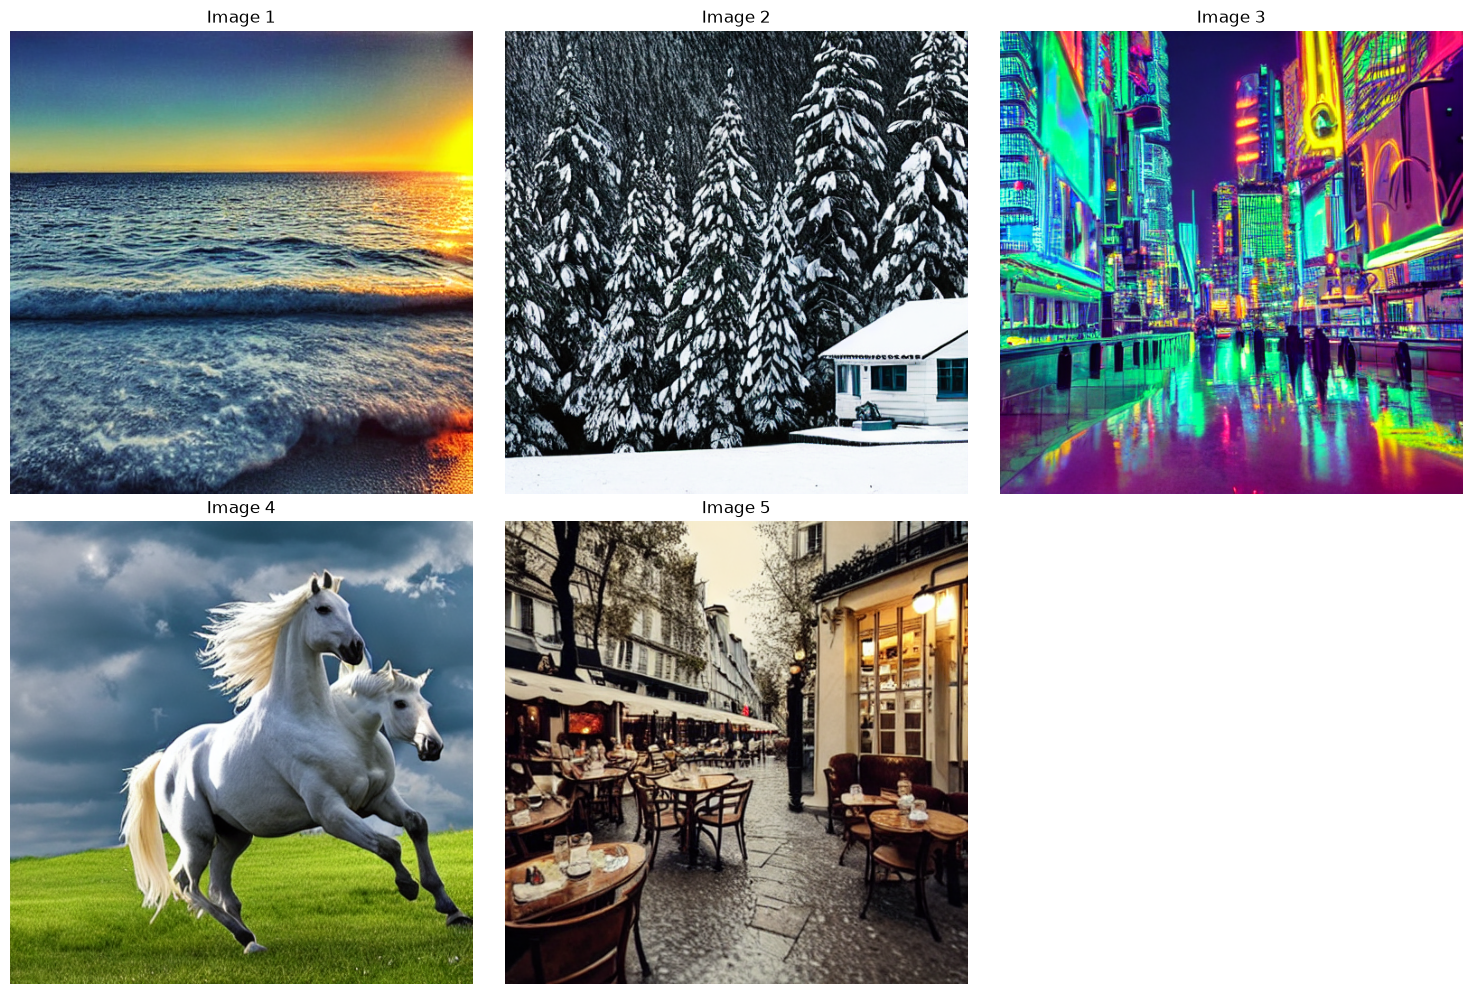

In [10]:
plt.figure(figsize=(15, 10))

for i, image in enumerate(images):
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title("Image " + str(i + 1))

plt.tight_layout()
plt.show()

In [11]:
for i, image in enumerate(images):
    image.save("generated_image_" + str(i + 1) + ".png")
print("All images saved!")

All images saved!
